# Obesity Risk Analysis

This notebook analyzes obesity risk using demographic and education-related factors. The project applies logistic regression, cross-validation, threshold-based classification evaluation, and aggregated binomial modeling to study how age group, gender, and education level relate to obesity classification.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats 
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

In [2]:
project_root = Path.cwd()

# Load dataset
data_file = project_root / "obesity_data.txt"
obdata = pd.read_csv(data_file, sep=" ", quotechar='"', header=0)

In [3]:
# Data before aggregation
obdata['obesityind'] = obdata['Obesity'].astype('category').cat.rename_categories(["NotObese", "Obese"])
obdata['agegr'] = obdata['AgeGroup'].astype('category').cat.rename_categories(["18to24", "25to34", "35to44", "45to64", "65+"])
obdata['gender'] = obdata['Gender'].astype('category').cat.rename_categories(["Male", "Female"])
obdata['edu'] = obdata['Education'].astype('category').cat.rename_categories(["<9thGrade", "9to11Grade", "HighSchool", "SomeCollege", "College+"])

We relabel variables into meaningful labels for ease of reference later in the analysis.

### Barplots

The visualizations below compare obesity proportions across age group, gender, and education categories.

In [4]:
# Create contingency tables
tb_obage = pd.crosstab(index=obdata['obesityind'], columns=obdata['agegr'])
tb_obgender = pd.crosstab(index=obdata['obesityind'], columns=obdata['gender'])
tb_obedu = pd.crosstab(index=obdata['obesityind'], columns=obdata['edu'])

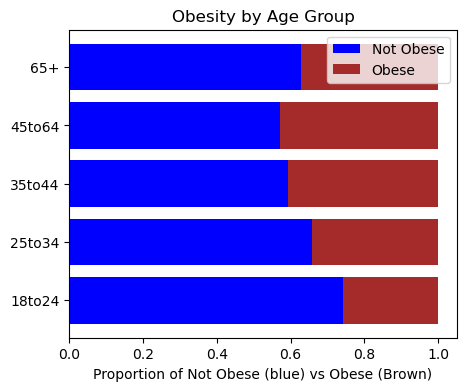

In [5]:
# Bar plot 1 - proportion within same group 
plt.figure(figsize=(5, 4))
plt.barh(tb_obage.columns, tb_obage.loc["NotObese"] / tb_obage.sum(axis=0), color='blue', label='Not Obese')
plt.barh(tb_obage.columns, tb_obage.loc["Obese"] / tb_obage.sum(axis=0), left=tb_obage.loc["NotObese"] / tb_obage.sum(axis=0), color='brown', label='Obese')
plt.xlabel('Proportion of Not Obese (blue) vs Obese (Brown)')
plt.title('Obesity by Age Group')
plt.legend()
plt.show()

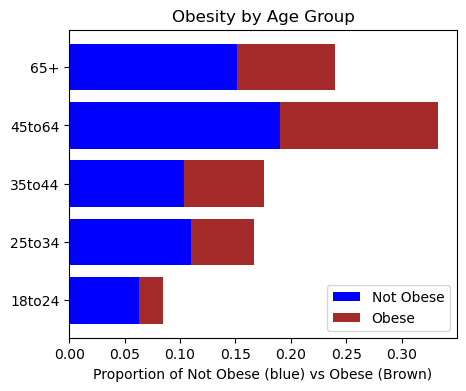

In [6]:
# Bar plot 1 - proportion within the entire table
tb_obage_prop = tb_obage / tb_obage.sum().sum()
plt.figure(figsize=(5, 4))
plt.barh(tb_obage.columns, tb_obage_prop.loc["NotObese"], color='blue', label='Not Obese')
plt.barh(tb_obage.columns, tb_obage_prop.loc["Obese"], left=tb_obage_prop.loc["NotObese"], color='brown', label='Obese')
plt.xlabel('Proportion of Not Obese (blue) vs Obese (Brown)')
plt.title('Obesity by Age Group')
plt.legend()
plt.show()

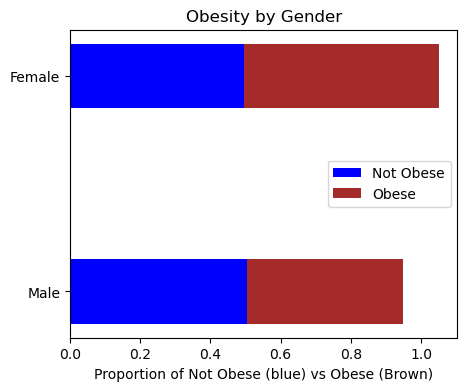

In [7]:
#Bar plot 2

# Normalize values within each category
tb_obgender_norm = tb_obgender.div(tb_obgender.sum(axis=1), axis=0)
# Plot bar chart
plt.figure(figsize=(5, 4))
plt.barh(tb_obgender_norm.columns, tb_obgender_norm.loc["NotObese"], height=0.3, color='blue', label='Not Obese')
plt.barh(tb_obgender_norm.columns, tb_obgender_norm.loc["Obese"],height=0.3, left=tb_obgender_norm.loc["NotObese"], color='brown', label='Obese')

plt.xlabel('Proportion of Not Obese (blue) vs Obese (Brown)')
plt.title('Obesity by Gender')
plt.legend()
plt.show()

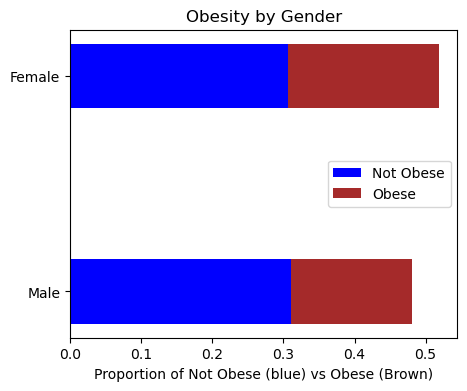

In [8]:
#Bar plot 2 - Compute proportions relative to the entire table
tb_obgender_prop = tb_obgender / tb_obgender.values.sum()
plt.figure(figsize=(5, 4))
plt.barh(tb_obgender_prop.columns, tb_obgender_prop.loc["NotObese"], height=0.3, color='blue', label='Not Obese')
plt.barh(tb_obgender_prop.columns, tb_obgender_prop.loc["Obese"], height=0.3, left=tb_obgender_prop.loc["NotObese"], color='brown', label='Obese')
plt.xlabel('Proportion of Not Obese (blue) vs Obese (Brown)')
plt.title('Obesity by Gender')
plt.legend()
plt.show()

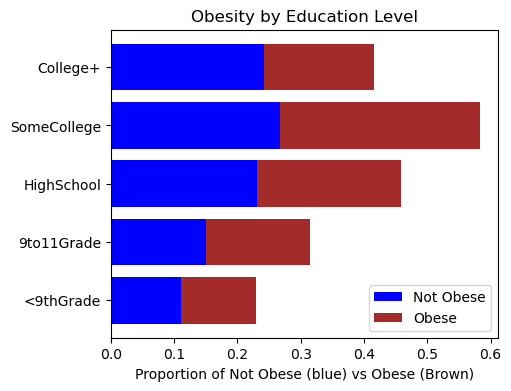

In [9]:
# Barplot 3
tb_obedu_norm = tb_obedu.div(tb_obedu.sum(axis=1), axis=0)
plt.figure(figsize=(5, 4))
plt.barh(tb_obedu_norm.columns, tb_obedu_norm.loc["NotObese"], color='blue', label='Not Obese')
plt.barh(tb_obedu_norm.columns, tb_obedu_norm.loc["Obese"], left=tb_obedu_norm.loc["NotObese"], color='brown', label='Obese')

plt.xlabel('Proportion of Not Obese (blue) vs Obese (Brown)')
plt.title('Obesity by Education Level')
plt.legend()
plt.show()

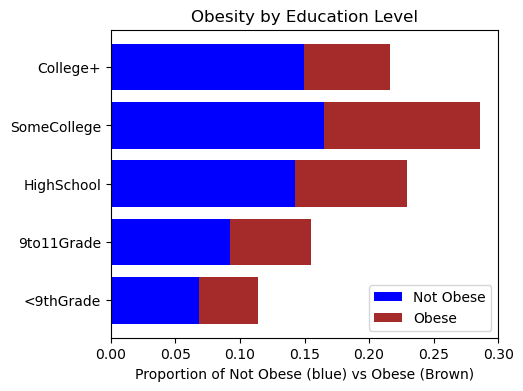

In [10]:
#Bar plot 3 - Compute proportions relative to the entire table
tb_obedu_prop = tb_obedu / tb_obedu.values.sum()
plt.figure(figsize=(5, 4))
plt.barh(tb_obedu_prop.columns, tb_obedu_prop.loc["NotObese"], color='blue', label='Not Obese')
plt.barh(tb_obedu_prop.columns, tb_obedu_prop.loc["Obese"], left=tb_obedu_prop.loc["NotObese"], color='brown', label='Obese')
plt.xlabel('Proportion of Not Obese (blue) vs Obese (Brown)')
plt.title('Obesity by Education Level')
plt.legend()
plt.show()

We use barplots to visualize the relationship between two categorical variables. There are differences in the proportions for each group and for each of the three predicting variables.

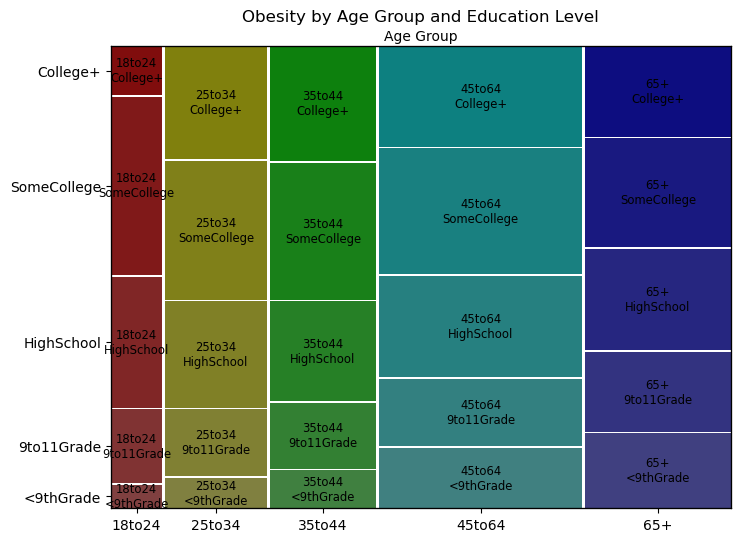

In [11]:
# Exploratory data analysis:  Predictors
tb_ageedu = pd.crosstab(index=obdata['agegr'], columns=obdata['edu'])

# Mosaic Plot
from statsmodels.graphics.mosaicplot import mosaic
fig, ax = plt.subplots(figsize=(8, 6))
mosaic(tb_ageedu.stack(), ax=ax, title='Obesity by Age Group and Education Level')
plt.xlabel('Age Group')
plt.ylabel('Education')
plt.show()

This is the mosaic plot. We can conclude from the plot that there is not a clear, strong relationship between these two variables.

In [12]:
# Logistic regression model
model = sm.formula.glm(formula='Obesity~agegr+gender+edu', data=obdata, family=sm.families.Binomial()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Obesity   No. Observations:                 4314
Model:                            GLM   Df Residuals:                     4304
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2820.6
Date:                Thu, 22 May 2025   Deviance:                       5641.3
Time:                        22:57:03   Pearson chi2:                 4.31e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02260
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.2058      0

Example of interpretation of coefficient agegr25to34: the ratio of the odds of obesity for age group 25-34 versus the age group 18-24 (the baseline) is 1.604 (or, equivalently the log odds ratio is 0.4727), holding all other predicting variables fixed which equivalents to the odds of obesity for age group 25-34 are 60.4% higher than for age group 18-24.

In [13]:
# Goodness-of-fit test
gstat = model.null_deviance - model.deviance
print(round(gstat,4), 1 - stats.chi2.cdf(gstat, len(model.params) - 1))

print(round(model.summary2().tables[1]['P>|z|'], 4))

98.6367 0.0
Intercept             0.0000
agegr[T.25to34]       0.0011
agegr[T.35to44]       0.0000
agegr[T.45to64]       0.0000
agegr[T.65+]          0.0000
gender[T.Female]      0.0003
edu[T.9to11Grade]     0.6451
edu[T.HighSchool]     0.7636
edu[T.SomeCollege]    0.2063
edu[T.College+]       0.0007
Name: P>|z|, dtype: float64


The p-value is approximate zero. So we reject the null hypothesis that all regression coefficients are zero which means at least one predicting variable has the explanatory power.

Check the p-values for statistical significance of individual coefficient.

In [14]:
## Is it meaningful to do a goodness of fit test? No.
## Is it meaningful to do a residual analysis? No. Logistic regression without repetitions

from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegressionCV

X = pd.get_dummies(obdata[['agegr', 'gender', 'edu']], drop_first=True)
y = obdata['Obesity']

model_cv = LogisticRegressionCV(cv=10, scoring='accuracy', random_state=42)
model_cv.fit(X, y)
cv_err = 1 - model_cv.score(X, y)
print("Cross-validated classification error:", round(cv_err,4))

Cross-validated classification error: 0.3825


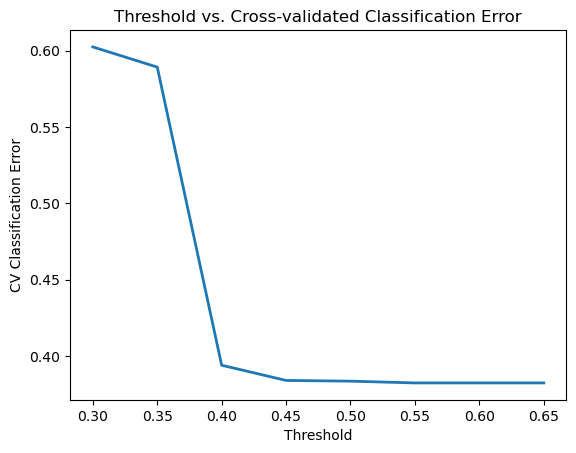

In [15]:
y_proba = cross_val_predict(model_cv, X, y, cv=10, method="predict_proba")[:, 1]

def cost(y, pi, threshold):
    y_pred = (pi > threshold).astype(int)
    err = np.mean(np.abs(y - y_pred))
    return err

thresholds = np.arange(0.3, 0.7, 0.05)  
cv_errors = [cost(y, y_proba, thresh) for thresh in thresholds]

# Plot classification error vs. threshold
plt.plot(thresholds, cv_errors, linestyle='-', linewidth=2)
plt.xlabel("Threshold")
plt.ylabel("CV Classification Error")
plt.title("Threshold vs. Cross-validated Classification Error")
plt.show()

We can estimate the classification error rate for any cost function such as 0.35, 0.40 etc. The plot of classification error rates versus different thresholds are shown above. It shows that the classification error is high for small thresholds and decreases for higher thresholds. In fact, the prediction accuracy is highest and stays the same for thresholds higher than 0.5.

## Prediction on New Observations

### Prediction Using Test Data

In [16]:
# Load test dataset
project_root = Path.cwd()

# Load dataset
data_file_test = project_root / "obesity_test_data.txt"
testobdata = pd.read_csv(data_file_test, sep=" ", quotechar='"', header=0)

testobdata['agegr'] = testobdata['AgeGroup'].astype('category').cat.rename_categories(["18to24", "25to34", "35to44", "45to64", "65+"])
testobdata['gender'] = testobdata['Gender'].astype('category').cat.rename_categories(["Male", "Female"])
testobdata['edu'] = testobdata['Education'].astype('category').cat.rename_categories(["<9thGrade", "9to11Grade", "HighSchool", "SomeCollege", "College+"])

pred_data = pd.DataFrame({'agegr': testobdata['agegr'], 'gender': testobdata['gender'], 'edu': testobdata['edu']})
pred_test = model.predict(pred_data)

In [17]:
def cost0_3(y, pi):
    y_pred = np.zeros(len(y))
    y_pred[pi > 0.3] = 1
    err = np.mean(np.abs(y - y_pred))
    return err

def cost0_35(y, pi):
    y_pred = np.zeros(len(y))
    y_pred[pi > 0.35] = 1
    err = np.mean(np.abs(y - y_pred))
    return err

def cost0_4(y, pi):
    y_pred = np.zeros(len(y))
    y_pred[pi > 0.4] = 1
    err = np.mean(np.abs(y - y_pred))
    return err

def cost0_45(y, pi):
    y_pred = np.zeros(len(y))
    y_pred[pi > 0.45] = 1
    err = np.mean(np.abs(y - y_pred))
    return err

def cost0_5(y, pi):
    y_pred = np.zeros(len(y))
    y_pred[pi > 0.5] = 1
    err = np.mean(np.abs(y - y_pred))
    return err

def cost0_55(y, pi):
    y_pred = np.zeros(len(y))
    y_pred[pi > 0.55] = 1
    err = np.mean(np.abs(y - y_pred))
    return err

def cost0_6(y, pi):
    y_pred = np.zeros(len(y))
    y_pred[pi > 0.6] = 1
    err = np.mean(np.abs(y - y_pred))
    return err

def cost0_65(y, pi):
    y_pred = np.zeros(len(y))
    y_pred[pi > 0.65] = 1
    err = np.mean(np.abs(y - y_pred))
    return err

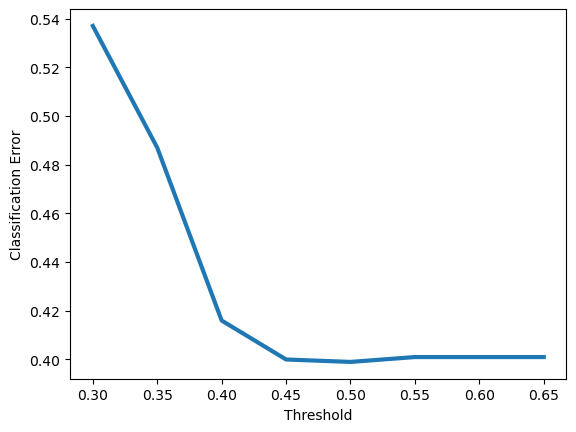

In [18]:
error_3 = cost0_3(testobdata['Obesity'], pred_test)
error_35 = cost0_35(testobdata['Obesity'], pred_test)
error_4 = cost0_4(testobdata['Obesity'], pred_test)
error_45 = cost0_45(testobdata['Obesity'], pred_test)
error_5 = cost0_5(testobdata['Obesity'], pred_test)
error_55 = cost0_55(testobdata['Obesity'], pred_test)
error_6 = cost0_6(testobdata['Obesity'], pred_test)
error_65 = cost0_65(testobdata['Obesity'], pred_test)

x = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65]
err = [error_3, error_35, error_4, error_45, error_5, error_55, error_6, error_65]

plt.plot(x, err, linewidth=3)
plt.xlabel('Threshold')
plt.ylabel('Classification Error')
plt.show()

We evaluate prediction accuracy using 1000 individuals as the test data and apply the same cost function to get the classification error rates.

We can see a similar pattern as for the classification error rates estimated using the cross-validation approach. A large classification error for small thresholds and a smaller classification error for larger thresholds.

The prediction accuracy using the fitted model did not improve for the test data. This is in contrast to the overall regression test which concluded the model has explanatory power. Thus, while the predicting factor may be associated with the probability of being obese or not, they are not sufficient to provide a good prediction. Other factors should be included in the model.

## Aggregated Logistic Regression

### Aggregated Binomial Modeling

In [19]:
from scipy.stats import chi2

obdata_agg_n = obdata.groupby(['edu', 'gender', 'agegr']).size().reset_index(name='Total')
obdata_agg_y = obdata.groupby(['edu', 'gender', 'agegr']).agg({'Obesity': 'sum'}).reset_index()
obdata_agg_y = obdata_agg_y.rename(columns={'gender': 'Gender', 'agegr': 'AgeGroup', 'edu': 'Education'})

agegr_agg = obdata_agg_n['agegr'].astype('category').cat.rename_categories(["18to24", "25to34", "35to44", "45to64", "65+"])
gender_agg = obdata_agg_n['gender'].astype('category').cat.rename_categories(["Male", "Female"])
edu_agg = obdata_agg_n['edu'].astype('category').cat.rename_categories(["<9thGrade", "9to11Grade", "HighSchool", "SomeCollege", "College+"])

obdata_agg = pd.DataFrame({
    'obdata_obesity': obdata['Obesity'],
    'Obesity': obdata_agg_y['Obesity'],
    'Total': obdata_agg_n['Total'],
    'agegr': agegr_agg,
    'gender': gender_agg,
    'edu': edu_agg,
    'TotalMinusObesity': obdata_agg_n['Total'] - obdata_agg_y['Obesity']
})
obdata_agg['Obesity'] = obdata_agg['Obesity'].fillna(0).astype('int')
obdata_agg['Total'] = obdata_agg['Total'].fillna(0).astype('int')

# Fitting the logistic regression model
model_agg = sm.formula.glm(formula='np.column_stack((Obesity, TotalMinusObesity)) ~ agegr + gender + edu', data=obdata_agg, family=sm.families.Binomial()).fit()

We aggregate the response data in a way that we will convert the binary data without replications into binary data with replications. This can be done only when all the predicting variables are categorical.

### Test for overall regression

In [20]:
g_stat = model_agg.null_deviance - model_agg.deviance
print(np.array([round(g_stat,4), 1 - chi2.cdf(g_stat, len(model_agg.params) - 1)]))

[98.6367  0.    ]


It calculates likelihood ratio test statistic for evaluating the goodness of fit compared to a null model. The large gstat suggests that the model provides a significant better fit than the null model. The p-value is approximate zero indicating the model is a good fit.

### Test for GOF: Using deviance residuals

In [21]:
deviances2 = model_agg.resid_deviance
dev_t_value = np.sum(deviances2**2)
print(np.array([round(dev_t_value,4), round(1 - chi2.cdf(dev_t_value, model_agg.df_resid),4)]))

[29.064   0.8997]


The p-value is 0.8997, indicating that the model fits the data well.

### Residual Analysis

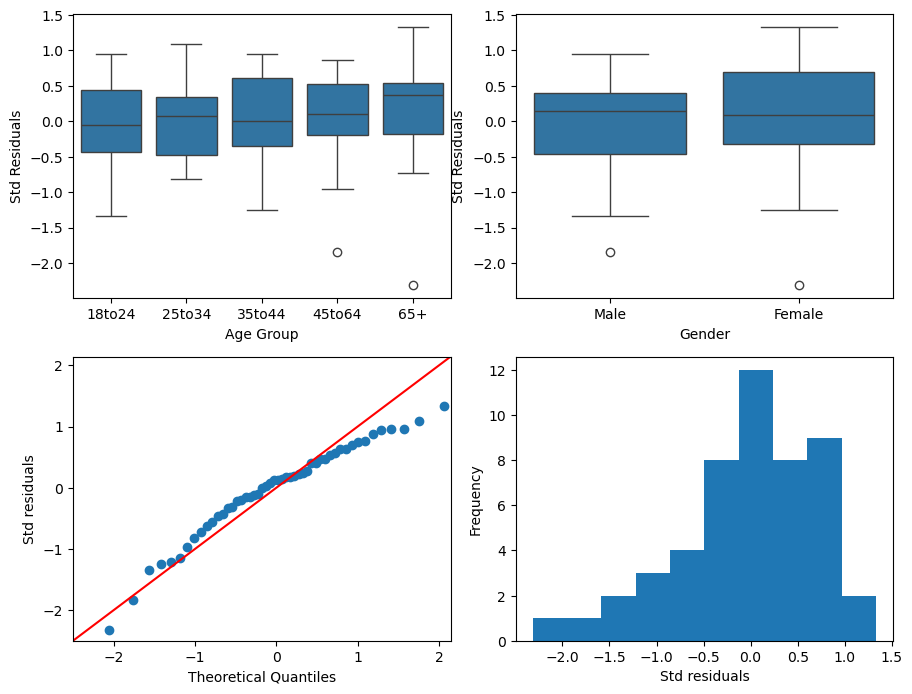

In [22]:
fig, axes = plt.subplots(2, 2, figsize=((9, 7)))

res_df1 = pd.DataFrame({'residuals': deviances2, 'agegr':agegr_agg})
res_df2 = pd.DataFrame({'residuals': deviances2, 'gender':gender_agg})

# Boxplot for Age Group
sns.boxplot(x='agegr', y='residuals', data=res_df1, ax=axes[0, 0])
axes[0, 0].set(xlabel='Age Group', ylabel='Std Residuals')

# Boxplot for Gender
sns.boxplot(x='gender', y='residuals', data=res_df2, ax=axes[0, 1])
axes[0, 1].set(xlabel='Gender', ylabel='Std Residuals')

# QQ plot
sm.qqplot(deviances2, line='45', ax=axes[1, 0])
axes[1, 0].set_ylabel('Std residuals')

# Histogram
axes[1, 1].hist(deviances2, bins=10)
axes[1, 1].set_xlabel('Std residuals')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

We do not need to evaluate linear assumption since all predicting variables are categorical.

There is no significant variability in the residuals between the group medians for age groups and for gender. Thus, the model explains the variability due to these predicting factors. As for normality, the distribution of the residuals is somewhat skewed, potentially an indication of some departures from a good fit. 

### Residual Analysis

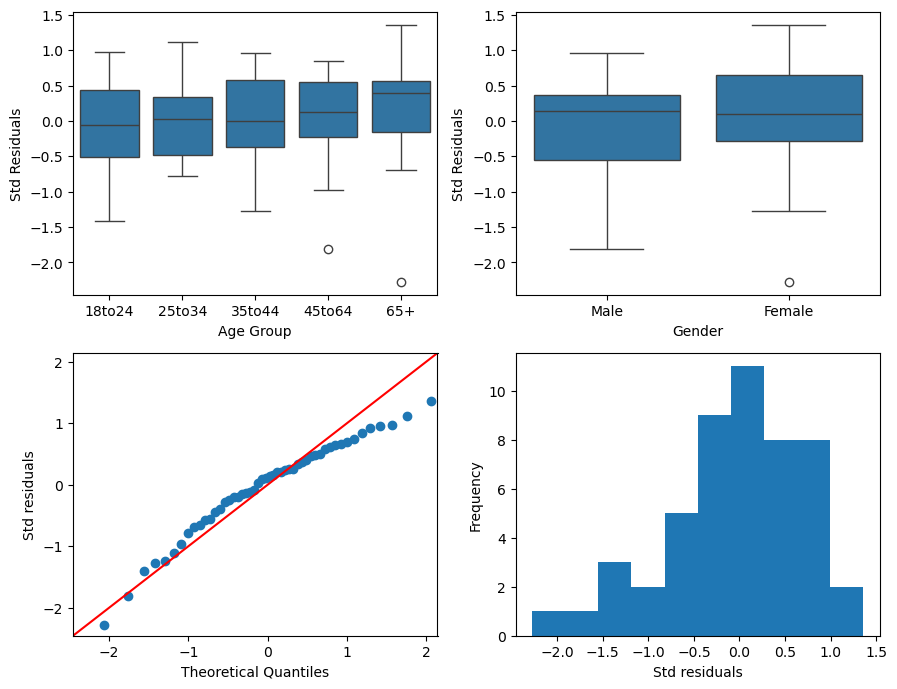

In [23]:
model_agg_2 = sm.GLM.from_formula('np.column_stack((Obesity,TotalMinusObesity)) ~ agegr + gender + edu',
                                  family=sm.families.Binomial(link=sm.families.links.cloglog()),
                                  data=obdata_agg).fit()

fig, axes = plt.subplots(2, 2, figsize=(9, 7))

res = model_agg_2.resid_deviance
res_df1 = pd.DataFrame({'residuals': res, 'agegr':agegr_agg})
res_df2 = pd.DataFrame({'residuals': res, 'gender':gender_agg})

# Boxplot for Age Group
sns.boxplot(x='agegr', y='residuals', data=res_df1, ax=axes[0, 0])
axes[0, 0].set(xlabel='Age Group', ylabel='Std Residuals')

# Boxplot for Gender
sns.boxplot(x='gender', y='residuals', data=res_df2, ax=axes[0, 1])
axes[0, 1].set(xlabel='Gender', ylabel='Std Residuals')

# QQ plot
sm.qqplot(res, line='45', ax=axes[1, 0])
axes[1, 0].set_ylabel('Std residuals')

# Histogram
axes[1, 1].hist(res, bins=10)
axes[1, 1].set_xlabel('Std residuals')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Another model with clog.log link function is performed. However, it does not show the improvement in the residual analysis.